In [17]:
from sklearn.datasets import load_diabetes
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

## Prepare Datasets and Train Test model

In [3]:
data = load_diabetes()
x = data.data
y = (data.target > data.target.mean()).astype(int) #แปลงค่า y จาก Regression (ตัวเลขต่อเนื่อง) ให้เป็น Binary Classification (0 หรือ 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)



# Train Model

In [4]:

Logis = LogisticRegression(random_state=0)
Ridge = RidgeClassifier(random_state=0)

Logis.fit(x_train, y_train)
Ridge.fit(x_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details.",0
,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.For an illustration of the effect of alpha on the model coefficients, see:ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,

## คำนวณค่า Confusion Matrix ที่ Decision Threshold เริ่มต้น ($0.5$)
### วิธีทำ
1. ทำนายเป็น Class Predictions (ใช้ Default Threshold ของแต่ละโมเดล)
2. คำนวณ Confusion Matrix

In [5]:
# step 1 
y_pre_logis = Logis.predict(x_test) # ตัดความน่าจะเป็นที่ Threshold = 0.5
y_pre_ridge = Ridge.predict(x_test) # ตัด Decision Function ที่ Threshold = 0

# step 2
cm_logis = confusion_matrix(y_test, y_pre_logis).ravel()
cm_ridge = confusion_matrix(y_test, y_pre_ridge).ravel()

print("Logistic Regression Confusion Matrix:")
print(cm_logis)

print("\nRidge Classifier Confusion Matrix:")
print(cm_ridge)


Logistic Regression Confusion Matrix:
[49  1 20 19]

Ridge Classifier Confusion Matrix:
[43  7 16 23]


### Sensitivity / True Positive Rate (TPR): $\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}$
#### model Logistic Regression

In [6]:
from sklearn.metrics import recall_score

sensitivity_logis_micro = recall_score(y_test, y_pre_logis, average='micro')
sensitivity_logis_macro = recall_score(y_test, y_pre_logis, average='macro')

sensitivity_ridge_micro = recall_score(y_test, y_pre_ridge, average='micro')
sensitivity_ridge_macro = recall_score(y_test, y_pre_ridge, average='macro')

print("sensitivity_logis_micro = ", sensitivity_logis_micro)
print("sensitivity_logis_macro = ", sensitivity_logis_macro)
print("sensitivity_ridge_micro = ", sensitivity_ridge_micro)
print("sensitivity_ridge_macro = ", sensitivity_ridge_macro)

sensitivity_logis_micro =  0.7640449438202247
sensitivity_logis_macro =  0.7335897435897436
sensitivity_ridge_micro =  0.7415730337078652
sensitivity_ridge_macro =  0.7248717948717949


#### Ridge Classifier

In [7]:
sen_ridge_micro = recall_score(y_test, y_pre_logis, average='micro') 
sen_ridge_macro = recall_score(y_test, y_pre_logis, average='macro')

print("Macro = ", sen_ridge_macro)
print("\nMicro = ", sen_ridge_micro)

Macro =  0.7335897435897436

Micro =  0.7640449438202247


## Specificity: $\text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}}$
#### Logistic Regression
#### Ridge Classifier


In [8]:
specificity_logis_macro = recall_score(y_test, y_pre_logis, pos_label=0, average='macro')
specificity_logis_micro = recall_score(y_test, y_pre_logis, pos_label=0, average='micro') 

rid_macro = recall_score(y_test, y_pre_ridge, pos_label=0, average='macro')
rid_micro = recall_score(y_test, y_pre_ridge, pos_label=0, average='micro')

print("logis_macro = ", specificity_logis_macro)
print("\nlogis_Micro = ", specificity_logis_micro)

print("\nRidge macro = ", rid_macro)
print("\nRidge micro = ", rid_micro)

logis_macro =  0.7335897435897436

logis_Micro =  0.7640449438202247

Ridge macro =  0.7248717948717949

Ridge micro =  0.7415730337078652


C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1929: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1929: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1929: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1929: UserWar

### False Positive Rate (FPR): $\text{FPR} = 1 - \text{Specificity} = \frac{\text{FP}}{\text{FP} + \text{TN}}$
#### Logistic Regression
#### Ridge Classifier

In [9]:
from sklearn.metrics import classification_report

fpr_logis_macro = 1 - specificity_logis_macro
fpr_logis_micro = 1 - specificity_logis_micro

fpr_ridge_macro = 1 - rid_macro
fpr_ridge_micro = 1 - rid_micro

print("FPR Logis Macro = ", fpr_logis_macro)
print("FPR Logis Micro = ", fpr_logis_micro)
print("FPR Ridge Macro = ", fpr_ridge_macro)
print("FPR Ridge Micro = ", fpr_ridge_micro)

FPR Logis Macro =  0.2664102564102564
FPR Logis Micro =  0.2359550561797753
FPR Ridge Macro =  0.2751282051282051
FPR Ridge Micro =  0.2584269662921348


# Precision

In [10]:
from sklearn.metrics import precision_score

pre_logis_macro = precision_score(y_test, y_pre_logis, average='macro')
pre_logis_micro = precision_score(y_test, y_pre_logis, average='micro')

pre_ridge_macro = precision_score(y_test, y_pre_ridge, average='macro')
pre_ridge_micro = precision_score(y_test, y_pre_ridge, average='micro')

print("logis_macro = ", pre_logis_macro)
print("logis_micro = ", pre_logis_micro)
print("ridge_macro = ", pre_ridge_macro)
print("ridge_micro = ", pre_ridge_micro)

logis_macro =  0.8300724637681159
logis_micro =  0.7640449438202247
ridge_macro =  0.7477401129943503
ridge_micro =  0.7415730337078652


# Accuracy

In [11]:
from sklearn.metrics import accuracy_score

acc_logis = accuracy_score(y_test, y_pre_logis)
acc_ridge = accuracy_score(y_test, y_pre_ridge)

print("acc_logis = ", acc_logis)
print("acc_ridge = ", acc_ridge)

acc_logis =  0.7640449438202247
acc_ridge =  0.7415730337078652


### เปลี่ยนค่า Decision Threshold ในช่วง $0.0$ ถึง $1.0$ เพื่อหาจุด$(\text{FPR}, \text{TPR})$ ต่างๆ ของ Logistic Regression
#### วิธีทำ
1. ดึงค่า Probability ของคลาส 1
2. คำนวณ FPR, TPR และ Thresholds ทั้งหมด
3. แปลงเป็น DataFrame เพื่อดูผลลัพธ์

In [12]:
from sklearn.metrics import roc_curve
import pandas as pd

# step 1
y_prob_logis = Logis.predict_proba(x_test)[:, 1]

# step 2
fpr_array, tpr_array, thresholds = roc_curve(y_test, y_prob_logis)

# step 3
df_roc = pd.DataFrame({
    'Threshold': thresholds,
    'FPR': fpr_array,
    'TPR': tpr_array
})

df_roc.head()

,Threshold,FPR,TPR
0,inf,0.00,0.000000
1,0.701891,0.00,0.025641
2,0.532522,0.00,0.282051
3,0.525593,0.02,0.282051
4,0.501330,0.02,0.487179


### Ridge Classifier 
- RidgeClassifier ไม่มี Method predict_proba()
- ใช้ decision_function() ซึ่งผลลัพธ์จะเป็นค่า Decision Score (ไม่ใช่ค่าความน่าจะเป็นช่วง $0.0 - 1.0$)

In [13]:
y_score_ridge = Ridge.decision_function(x_test)
fpr_ridge, tpr_ridge, th_ridge = roc_curve(y_test, y_score_ridge) 

df_ridge = pd.DataFrame({
    'Thresholds': th_ridge,
    'FPR': fpr_ridge,
    'TPR': tpr_ridge
})
df_ridge.head()

,Thresholds,FPR,TPR
0,inf,0.00,0.000000
1,0.882063,0.00,0.025641
2,0.154865,0.00,0.358974
3,0.142527,0.04,0.358974
4,0.082892,0.04,0.512821


### พลอตเส้น ROC Curve โดยให้แกน X เป็น FPR ($1 - \text{Specificity}$) และแกน Y เป็น TPR ($\text{Sensitivity}$)
#### วิธีทำ
1. ใช้ RocCurveDisplay
2. พล็อต Logistic Regression
3. พล็อต Ridge Classifier
4. เพิ่มเส้น Baseline

#### วิธีดูกราฟของ ROC Curve
1. แกน X (FPR): ยิ่งเข้าใกล้ $0$ แสดงว่าโมเดลทำนายทายผิด (False Positive) น้อย
2. แกน Y (TPR): ยิ่งเข้าใกล้ $1$ แสดงว่าโมเดลตรวจจับคลาสจริงได้ครอบคลุม (Sensitivity สูง)
3. เส้นกราฟยิ่งโค้งเบนขึ้นไปทางมุมซ้ายบนมากเท่าไร: แสดงว่าโมเดลนั้นมีประสิทธิภาพดีมาก ค่า AUC จะยิ่งเข้าใกล้ $1.0$


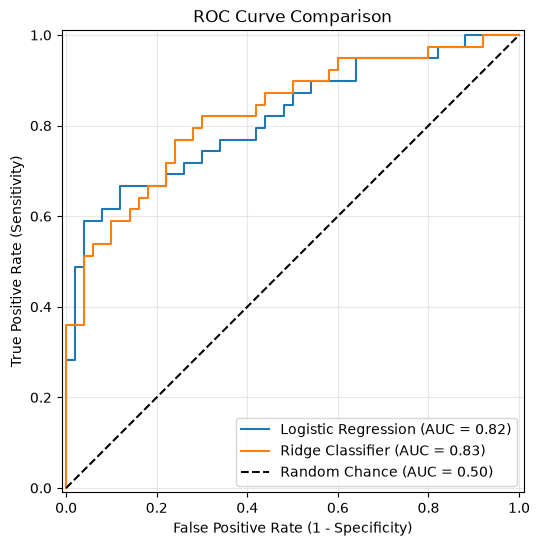

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

# step 2
RocCurveDisplay.from_estimator(Logis, x_test, y_test, ax=ax, name='Logistic Regression')

# step 3 
RocCurveDisplay.from_estimator(Ridge, x_test, y_test, ax=ax, name='Ridge Classifier')

# step 4
plt.plot([0,1],[0,1], 'k--', label='Random Chance (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

## คำนวณพื้นที่ใต้กราฟ AUC (Area Under the Curve) ของแต่ละโมเดล
### วิธีทำ
1. ดึงค่า Probability / Decision Score ของแต่ละโมเดล
   - Logistic Regression: ใช้ Probability ของคลาส 1
   - Ridge Classifier: ใช้ Decision Function Value
2. คำนวณค่า AUC

### การแปลความหมายของค่า AUC
1. AUC = 1.0: โมเดลจำแนกได้อย่างสมบูรณ์แบบ (Perfect Classifier)
2. 0.8 <= AUC < 0.9: โมเดลมีประสิทธิภาพดีมาก (Good Performance)
3. 0.7 <= AUC < 0.8: โมเดลมีประสิทธิภาพพอใช้ (Acceptable Performance)
4. AUC = 0.5: โมเดลมีประสิทธิภาพเท่ากับการเดาสุ่ม (Random Guessing)

In [15]:
from sklearn.metrics import roc_auc_score

auc_logis = roc_auc_score(y_test, y_prob_logis)
auc_ridge = roc_auc_score(y_test, y_score_ridge)

print("Logis = ", auc_logis)
print("Ridge = ", auc_ridge)

Logis =  0.8174358974358974
Ridge =  0.8271794871794872


## วิธีหา Threshold ที่ได้ Sensitivity ตามเป้าหมาย
1. ดึงค่า Probability ของคลาส 1 จาก Logistic Regression
2. ตั้งเป้าหมาย Sensitivity ที่ต้องการ
3. สร้างช่วง Threshold ที่ต้องการทดสอบ
4. เลือก Threshold ที่มากที่สุดแต่ยังได้ Sensitivity >= Target ยิ่ง Threshold สูงได้เท่าไร Precision ก็จะไม่ตกต่ำจนเกินไป
5. ทดสอบวัดผล ณ Threshold ใหม่ที่เลือกได้

In [16]:
import numpy as np
# step 1
y_prob_logis = Logis.predict_proba(x_test)[:, 1]

# step 2 
target_sensitivity = 0.99

# step 3 
thresholds = np.linspace(0.01, 0.99, 100)

best_th = None
for th in thresholds:
    y_pred = (y_prob_logis >= th).astype(int)
    current_sens = recall_score(y_test, y_pred)

    # step 4 
    if current_sens >= target_sensitivity:
        best_th = th
        
print(f"Target Sensitivity: {target_sensitivity * 100}%")

if best_th is not None:    
    print(f"Recommended Threshold: {best_th:.4f}\n")

    # step 5 
    y_pred_new = (y_prob_logis >= best_th).astype(int)
    
cm = confusion_matrix(y_test, y_pred_new)
tn, fp, fn, tp = cm.ravel()

actual_sens = tp / (tp + fn)
precision = tp / (tp + fp)
FPR = fp / (fp + tn)

if best_th is not None:
    print(f"--- Results at Threshold = {best_th:.4f} ---")
    
print(f"Sensitivity (TPR): {actual_sens:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"FPR:               {FPR:.4f}")
print(f"False Negatives:   {fn} คน (หลุดรอดน้อยลง)")
print(f"False Positives:   {fp} คน (แจ้งเตือนพลาดเพิ่มขึ้น)")

Target Sensitivity: 99.0%
Recommended Threshold: 0.2674

--- Results at Threshold = 0.2674 ---
Sensitivity (TPR): 1.0000
Precision:         0.4643
FPR:               0.9000
False Negatives:   0 คน (หลุดรอดน้อยลง)
False Positives:   45 คน (แจ้งเตือนพลาดเพิ่มขึ้น)


#### ให้นักศึกษาตอบคำถามต่อไปนี้ลงในรายงานสรุปผลการทดลอง
# 1. 
การเลือก Decision Threshold:
หากโจทย์นี้เป็นระบบคัดกรองทางการแพทย์ที่ต้องการให้หลุดตรวจพบผู้ป่วยน้อยที่สุด (เน้น Sensitivity สูง) เราควรปรับ Decision Threshold ให้สูงขึ้นหรือต่ำลง? และส่งผลต่อค่า FPR อย่างไร?

### ANS:
- ต้องกำหนด Threshold ให้ต่ำลง ส่งผลให้ค่า FPR มีค่ามากขึ้น ทำให้ model มีการทายผลผิดเพิ่มมากขึ้น ถ้า FPR มีค่าน้อยลงจะส่งผลให้ model ทำนายผิดว่าปกติมีจำนวนน้อยลง

# 2. 
ความหมายของค่า AUC:
ถ้าโมเดล A มีค่า $AUC = 0.88$ และโมเดล B มีค่า $AUC = 0.62$ โมเดลใดมีความสามารถในการแยกแยะ Class (Separation Power) ดีกว่ากัน เพราะเหตุใด?

### ANS
- A เพราะ ค่า AUC มากขึ้น ทำให้ความสามารถในการแยกแยะระหว่างสองคลาสดีกว่า model B

# 3. 
กรณี AUC ต่ำกว่า 0.5:
หากพล็อต ROC Curve แล้วได้ค่า $AUC < 0.5$ หมายความว่าอย่างไร และเกิดจากสาเหตุใดได้บ้าง?

### ANS
- ทำให้ model มีความสามารถในการแยกแยะคลาสได้ไม่ดีเหมือนกับการเดาสุ่ม เกิดจากการเกิด Overfitting อย่างรุนแรง อัตราส่วน TPR กับ FPR เท่ากัน

## 4. 
ความแตกต่างของ ROC Curve ในโมเดลที่ให้ Probabilities vs Non-Probabilities:
ทำไมโมเดลที่ผลลัพธ์ไม่เป็น Probability (เช่น Decision Tree ทั่วไป หรือ Non-probabilistic Classifier) จึงได้ ROC Curve ที่ลักษณะเป็นเหลี่ยมตักมากกว่าเส้นโค้งเรียบ?

### ANS
- สาเหตุที่ Non-probabilistic classifier เป็นแบบนั้นเพราะเกิดจาก ความละเอียดของผลลัพธ์มีลักษณะไม่ต่อเนื่อง 